In [1]:
# Wine Quality ML Pipeline - 환경 설정 및 데이터 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')
%matplotlib inline

# UCI Wine Quality CSV URLs (red + white)
URL_RED = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
URL_WHITE = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df_red = pd.read_csv(URL_RED, sep=';')
df_white = pd.read_csv(URL_WHITE, sep=';')
df_red['type'] = 'red'
df_white['type'] = 'white'
df = pd.concat([df_red, df_white], ignore_index=True)
print('Shape:', df.shape)
print(df.head())

Shape: (6497, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8    

결측치: 0

quality 분포:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


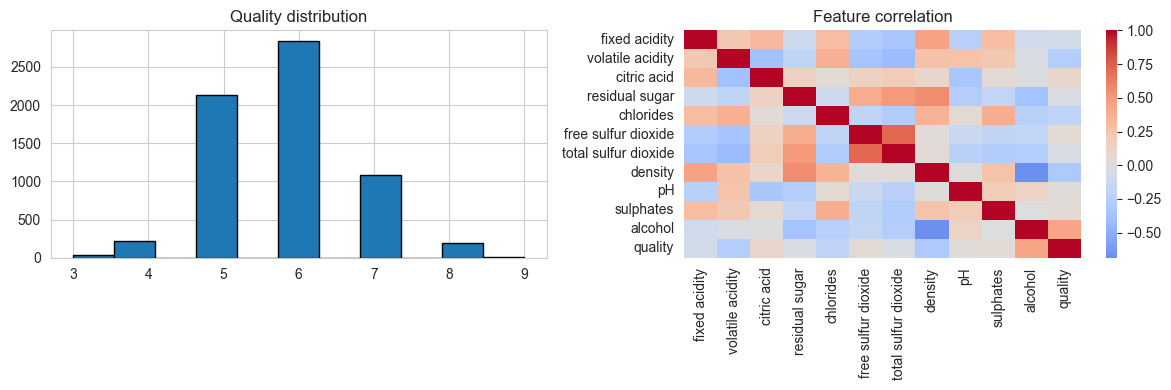

In [2]:
# EDA: 품질 분포, 결측치, 상관
print('결측치:', df.isnull().sum().sum())
print('\nquality 분포:')
print(df['quality'].value_counts().sort_index())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['quality'].hist(ax=axes[0], bins=11, edgecolor='black')
axes[0].set_title('Quality distribution')
sns.heatmap(df.drop(columns=['type']).corr(), ax=axes[1], cmap='coolwarm', center=0, fmt='.2f')
axes[1].set_title('Feature correlation')
plt.tight_layout()
plt.show()

In [3]:
# 타깃: 품질 구간 분류 (0-4: poor, 5-6: normal, 7-10: good)
def quality_to_class(q):
    if q <= 4: return 0
    if q <= 6: return 1
    return 2

df['quality_class'] = df['quality'].map(quality_to_class)
CLASS_NAMES = ['poor', 'normal', 'good']
print('quality_class 분포:')
print(df['quality_class'].value_counts().sort_index())
print('라벨:', CLASS_NAMES)

quality_class 분포:
quality_class
0     246
1    4974
2    1277
Name: count, dtype: int64
라벨: ['poor', 'normal', 'good']


In [4]:
# Feature 순서 고정 (API/프론트와 동일하게 유지)
FEATURE_ORDER = [
    'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
    'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]
X = df[FEATURE_ORDER]
y = df['quality_class']

In [5]:
# Train/Test 분할 및 StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train size:', X_train.shape[0], 'Test size:', X_test.shape[0])

Train size: 5197 Test size: 1300


In [6]:
# 모델 비교 (분류: F1-macro)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(probability=True, random_state=42),
}
results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-macro': f1_score(y_test, y_pred, average='macro')
    })
results_df = pd.DataFrame(results)
print(results_df)
best_name = results_df.loc[results_df['F1-macro'].idxmax(), 'Model']
print(f'\nBest model (F1-macro): {best_name}')

                 Model  Accuracy  F1-macro
0  Logistic Regression  0.784615  0.434171
1        Random Forest  0.853846  0.589948
2                  SVC  0.790000  0.427034

Best model (F1-macro): Random Forest


In [7]:
# 최종 모델 및 아티팩트 저장 (models/)
import joblib
import json
import os

# cwd가 notebooks/ 이면 ../models, 프로젝트 루트면 models/
MODELS_DIR = Path('../models') if Path('.').resolve().name == 'notebooks' else Path('models')
MODELS_DIR = MODELS_DIR.resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

best_model = fitted_models[best_name]
joblib.dump(best_model, MODELS_DIR / 'model.joblib')
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
with open(MODELS_DIR / 'feature_order.json', 'w') as f:
    json.dump(FEATURE_ORDER, f, indent=2)
with open(MODELS_DIR / 'class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f, indent=2)

# 예시 와인 샘플 (원본 스케일 값) - API /samples용
samples = df[FEATURE_ORDER].sample(n=min(10, len(df)), random_state=42)
samples_list = samples.to_dict(orient='records')
with open(MODELS_DIR / 'samples.json', 'w') as f:
    json.dump(samples_list, f, indent=2)

print('Saved to', MODELS_DIR)
print('  model.joblib, scaler.joblib, feature_order.json, class_names.json, samples.json')

Saved to /Users/LEEJIWOO/JuSeok/models
  model.joblib, scaler.joblib, feature_order.json, class_names.json, samples.json
